<a href="https://colab.research.google.com/github/albertbolanoss/labs_deep_learning/blob/fruit-single-shot-detection/notebooks/fruit-single-detector/01_yolo_v3_dark_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fruit single shot detector

## 0. Imports and global functions.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import tensorflow as tf
import xml.etree.ElementTree as ET
from google.colab import auth
from googleapiclient.discovery import build
from google.colab import userdata

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, BatchNormalization, LeakyReLU, Dropout, Reshape, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback, EarlyStopping
import tensorflow.keras.backend as K
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
import tensorflow as tf

from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload
import io
import os

# Request permissions to access (read/write) the Google Drive Folder ID
GOOGLE_DRIVE_FOLDER_ID = "14LvaZfifLwoGsnIbwINaEZMSLEpP4E4-"
auth.authenticate_user()
drive_service = build('drive', 'v3')


## 1. Download dataset.

In [2]:

KAGGLE_DATASET = "mbkinaci/fruit-images-for-object-detection"
BASE_DIR = "/content/fruit_data"
MODEL_TO_LOAD = "fruit_detector_v1.keras"
MODEL_TO_SAVE = "fruit_detector_v1.keras"

# Configurar Kaggle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Descargar y descomprimir
if not os.path.exists(BASE_DIR):
    print("Download dataset...")
    !kaggle datasets download -d {KAGGLE_DATASET}
    !unzip -q fruit-images-for-object-detection.zip -d {BASE_DIR}
    print(f"Dataset download in {BASE_DIR}")
else:
    print("The dataset has been already downloaded.")

# Verificar estructura
print("Dataset Folders:", os.listdir(BASE_DIR))

Download dataset...
Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
  0% 0.00/28.4M [00:00<?, ?B/s]
100% 28.4M/28.4M [00:00<00:00, 1.53GB/s]
Dataset download in /content/fruit_data
Dataset Folders: ['test_zip', 'train_zip']


# Task
Explore the dataset structure in `/content/fruit_data` (specifically `train_zip` and `test_zip`), then download YOLO v3 resources (`yolov3.cfg`, `yolov3.weights`, `coco.names`) to initialize the model with OpenCV, create a helper function to parse ground truth bounding boxes from XML files, and finally visualize a comparison between YOLO predictions and the ground truth on a sample of images.

## Explorar estructura del dataset

### Subtask:
Inspect the contents of the `train_zip` and `test_zip` folders to locate images and XML annotations.


**Reasoning**:
Construct paths for train and test directories, list their contents to verify the presence of images and XMLs, and count them to ensure data consistency.



In [3]:
train_dir = os.path.join(BASE_DIR, 'train_zip')
test_dir = os.path.join(BASE_DIR, 'test_zip')

# List files
train_files = os.listdir(train_dir)
test_files = os.listdir(test_dir)

print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# Print first 5 files
print("\nFirst 5 files in train_zip:", train_files[:5])
print("First 5 files in test_zip:", test_files[:5])

# Count images and xmls
train_images = [f for f in train_files if f.endswith('.jpg')]
train_xmls = [f for f in train_files if f.endswith('.xml')]

test_images = [f for f in test_files if f.endswith('.jpg')]
test_xmls = [f for f in test_files if f.endswith('.xml')]

print(f"\nTrain: {len(train_images)} images, {len(train_xmls)} xmls")
print(f"Test: {len(test_images)} images, {len(test_xmls)} xmls")

Train directory: /content/fruit_data/train_zip
Test directory: /content/fruit_data/test_zip

First 5 files in train_zip: ['train']
First 5 files in test_zip: ['test']

Train: 0 images, 0 xmls
Test: 0 images, 0 xmls


**Reasoning**:
The previous step revealed that `train_zip` and `test_zip` contain subdirectories named `train` and `test` respectively, rather than the files directly. I need to update the paths to point to these inner directories to correctly locate the images and XML files.



In [4]:
train_dir = os.path.join(BASE_DIR, 'train_zip', 'train')
test_dir = os.path.join(BASE_DIR, 'test_zip', 'test')

# List files in the corrected paths
train_files = os.listdir(train_dir)
test_files = os.listdir(test_dir)

print(f"Corrected Train directory: {train_dir}")
print(f"Corrected Test directory: {test_dir}")

# Print first 5 files
print("\nFirst 5 files in corrected train_dir:", train_files[:5])
print("First 5 files in corrected test_dir:", test_files[:5])

# Count images and xmls
train_images = [f for f in train_files if f.endswith('.jpg')]
train_xmls = [f for f in train_files if f.endswith('.xml')]

test_images = [f for f in test_files if f.endswith('.jpg')]
test_xmls = [f for f in test_files if f.endswith('.xml')]

print(f"\nTrain: {len(train_images)} images, {len(train_xmls)} xmls")
print(f"Test: {len(test_images)} images, {len(test_xmls)} xmls")

Corrected Train directory: /content/fruit_data/train_zip/train
Corrected Test directory: /content/fruit_data/test_zip/test

First 5 files in corrected train_dir: ['apple_64.jpg', 'apple_32.xml', 'apple_26.jpg', 'apple_46.jpg', 'apple_13.xml']
First 5 files in corrected test_dir: ['orange_82.jpg', 'banana_87.xml', 'banana_90.jpg', 'apple_83.xml', 'banana_82.xml']

Train: 240 images, 240 xmls
Test: 60 images, 60 xmls


## Descargar recursos de YOLO v3

### Subtask:
Download the YOLO v3 configuration file, pre-trained weights, and COCO class names.


**Reasoning**:
I will download the YOLO v3 configuration file, pre-trained weights, and COCO class names using `wget` to ensure the model can be initialized.



In [5]:
# Download YOLO v3 configuration
!wget -O yolov3.cfg https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true

# Download YOLO v3 weights
!wget -O yolov3.weights https://pjreddie.com/media/files/yolov3.weights

# Download COCO class names
!wget -O coco.names https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true

print("YOLO v3 resources downloaded successfully.")

--2026-03-03 02:38:48--  https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg [following]
--2026-03-03 02:38:48--  https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/pjreddie/darknet/refs/heads/master/cfg/yolov3.cfg [following]
--2026-03-03 02:38:48--  https://raw.githubusercontent.com/pjreddie/darknet/refs/heads/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
H

**Reasoning**:
With the resources downloaded, the next step is to initialize the YOLO v3 model using OpenCV's DNN module and load the COCO class names.



In [6]:
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

print("YOLO v3 model loaded successfully.")
print(f"Loaded {len(classes)} classes.")

YOLO v3 model loaded successfully.
Loaded 80 classes.


## Función para leer Ground Truth

### Subtask:
Create a helper function to parse ground truth bounding boxes and class labels from XML files.


**Reasoning**:
I will define the `parse_annotation` function to extract bounding boxes and class labels from the XML files, which is necessary for comparing ground truth with model predictions.



In [7]:
def parse_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    objects = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        objects.append({
            'name': name,
            'bbox': [xmin, ymin, xmax, ymax]
        })

    return objects

print("parse_annotation function defined.")

parse_annotation function defined.


## Detectar y Visualizar Comparación

### Subtask:
Select a sample of images, perform object detection using the loaded YOLO model, and visualize the results by overlaying both the model predictions and the ground truth annotations on the images.


**Reasoning**:
I will select a random sample of 3 images from the test set, perform object detection using the loaded YOLO model, and visualize the results by overlaying both the model predictions (in Red) and the ground truth annotations (in Green) on the images.



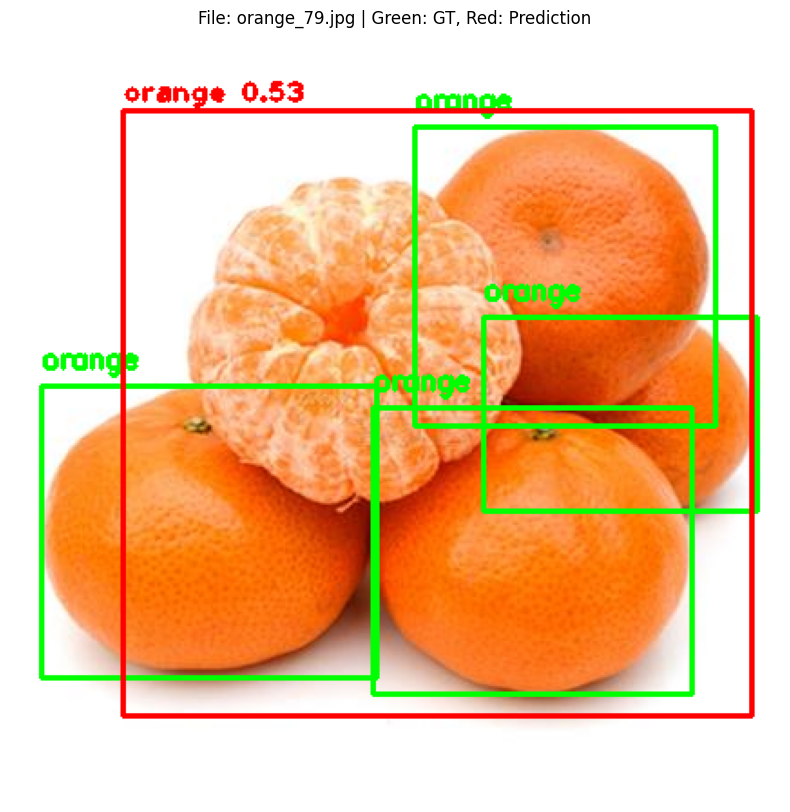

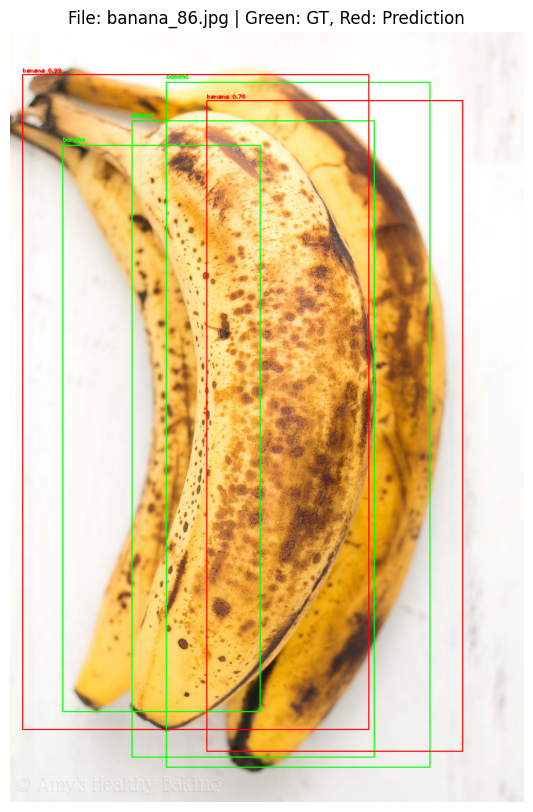

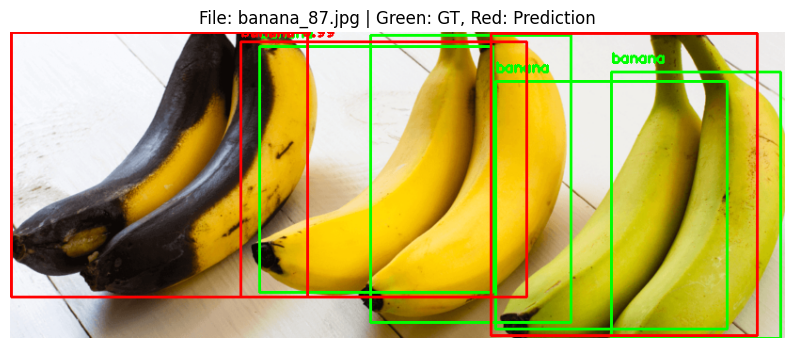

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# 1. Select a random sample of 3 image filenames
random.seed(51) # For reproducibility
sample_images = random.sample(test_images, 3)

for img_file in sample_images:
    # a. Construct full file paths
    img_path = os.path.join(test_dir, img_file)
    xml_file = img_file.replace('.jpg', '.xml')
    xml_path = os.path.join(test_dir, xml_file)

    # b. Parse ground truth
    gt_objects = parse_annotation(xml_path)

    # c. Load image
    img = cv2.imread(img_path)
    height, width, channels = img.shape

    # d. Create blob
    blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)

    # e. Set input and forward pass
    net.setInput(blob)
    outs = net.forward(output_layers)

    # f. Process detections
    class_ids = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                # Object detected
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # Rectangle coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # g. Apply NMS
    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    # h. Visualization
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))

    # Draw Ground Truth (Green)
    for obj in gt_objects:
        bbox = obj['bbox']
        cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img_rgb, obj['name'], (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Draw Predictions (Red)
    font = cv2.FONT_HERSHEY_PLAIN
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            confidence = confidences[i]
            color = (255, 0, 0) # Red
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img_rgb, f"{label} {confidence:.2f}", (x, y - 5), font, 1, color, 2)

    # i. Display
    plt.imshow(img_rgb)
    plt.title(f"File: {img_file} | Green: GT, Red: Prediction")
    plt.axis('off')
    plt.show()

## Final Task

### Subtask:
Summarize the visual comparison between YOLO predictions and ground truth annotations.
